In [1]:
import arviz as az
import polars as pl
import bambi as bmb
from matplotlib import pyplot as plt

In [2]:
msts = pl.read_csv("data/prepared/bfi.csv")

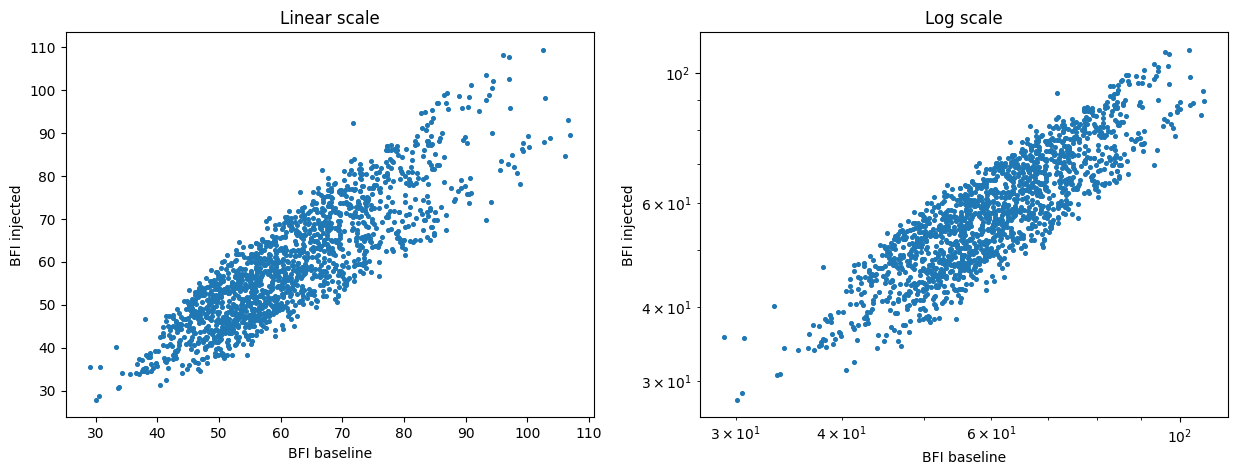

In [3]:
f, axes = plt.subplots(1, 2, figsize=[15, 5])
for ax in axes:
    ax.scatter(msts["bfi_baseline"], msts["bfi_injected"], s=7);
    ax.set(xlabel="BFI baseline", ylabel="BFI injected");
axes[0].set_title("Linear scale");
axes[1].set_title("Log scale");
axes[1].semilogx();
axes[1].semilogy();


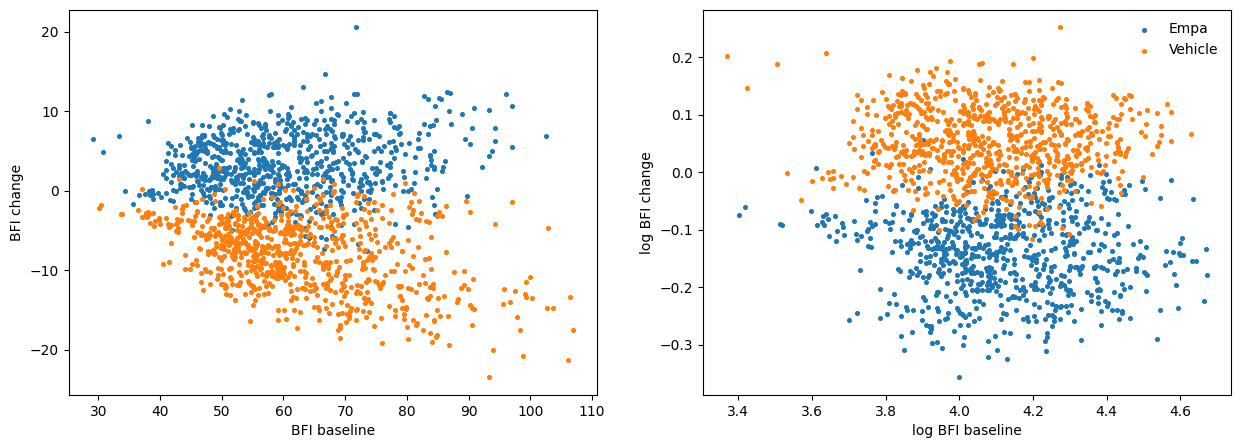

In [4]:
f, axes = plt.subplots(1, 2, figsize=[15, 5])
for ax, prefix in zip(axes, ["", "log_"]):
    for (treatment,), subdf in msts.group_by(["treatment"]):
        ax.scatter(subdf[prefix + "bfi_baseline"], subdf[prefix + "bfi_change"], s=7, label=treatment);
axes[0].set(xlabel="BFI baseline", ylabel="BFI change");
axes[1].set(xlabel="log BFI baseline", ylabel="log BFI change")
ax.legend(frameon=False)

In [5]:
FORMULA = "{y} ~ (1|rat) + treatment + gtyp + age + sex + gtyp:age"

In [6]:
formula_linear = bmb.Formula(FORMULA.format(y="bfi_change"))
model_linear = bmb.Model(formula=formula_linear, data=msts.to_pandas())
idata_linear = model_linear.fit()
model_linear.predict(idata_linear, data=msts.to_pandas(), kind="response", inplace=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, treatment, gtyp, age, sex, gtyp:age, 1|rat_sigma, 1|rat_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


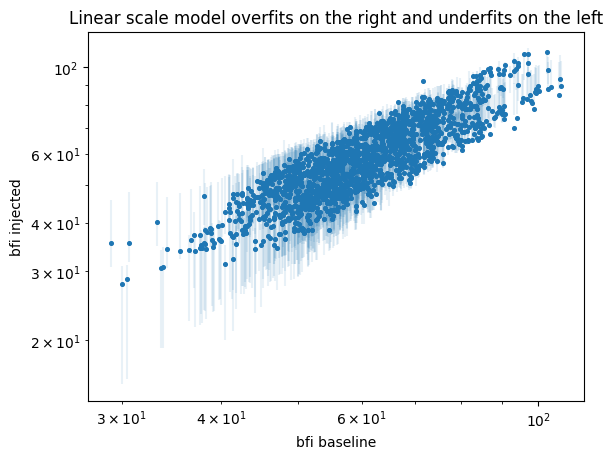

In [11]:
qlow_linear, qhigh_linear = (
    idata_linear.posterior_predictive["bfi_change"]
    .quantile([0.01, 0.99], dim=["chain", "draw"])
    .to_numpy()
)
plot_df = msts.with_columns(
    bfi_change_q1=qlow_linear,
    bfi_change_q99=qhigh_linear,
)
f, ax = plt.subplots()
ax.scatter(plot_df["bfi_baseline"], plot_df["bfi_injected"], s=7);
ax.vlines(
    plot_df["bfi_baseline"], 
    plot_df["bfi_change_q1"] + plot_df["bfi_baseline"], 
    plot_df["bfi_change_q99"]+ plot_df["bfi_baseline"],
    zorder=10,
    alpha=0.1
);
ax.set(
    xlabel="bfi baseline", 
    ylabel="bfi injected",
    title="Linear scale model overfits on the right and underfits on the left"
);
ax.semilogx();
ax.semilogy();

In [8]:
formula_log = bmb.Formula(FORMULA.format(y="log_bfi_change"))
model_log = bmb.Model(formula=formula_log, data=msts.to_pandas())
idata_log = model_log.fit()
model_log.predict(idata_log, data=msts.to_pandas(), kind="response", inplace=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, treatment, gtyp, age, sex, gtyp:age, 1|rat_sigma, 1|rat_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


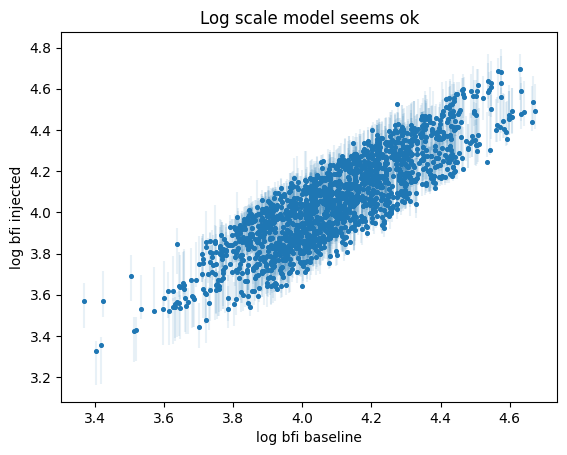

In [9]:
qlow_log, qhigh_log = (
    idata_log.posterior_predictive["log_bfi_change"]
    .quantile([0.01, 0.99], dim=["chain", "draw"])
    .to_numpy()
)
plot_df = msts.with_columns(
    log_bfi_change_q1=qlow_log,
    log_bfi_change_q99=qhigh_log,
)
f, ax = plt.subplots()
ax.scatter(plot_df["log_bfi_baseline"], plot_df["log_bfi_injected"], s=7);
ax.vlines(
    plot_df["log_bfi_baseline"], 
    plot_df["log_bfi_change_q1"] + plot_df["log_bfi_baseline"], 
    plot_df["log_bfi_change_q99"]+ plot_df["log_bfi_baseline"],
    zorder=10,
    alpha=0.1
);
ax.set(
    xlabel="log bfi baseline", 
    ylabel="log bfi injected",
    title="Log scale model seems ok"
);


array([[<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'treatment\nVehicle'}>,
        <Axes: title={'center': 'gtyp\nfa/fa'}>],
       [<Axes: title={'center': 'age\nYoung'}>,
        <Axes: title={'center': 'sex\nM'}>,
        <Axes: title={'center': 'gtyp:age\nfa/fa, Young'}>,
        <Axes: title={'center': '1|rat_sigma'}>]], dtype=object)

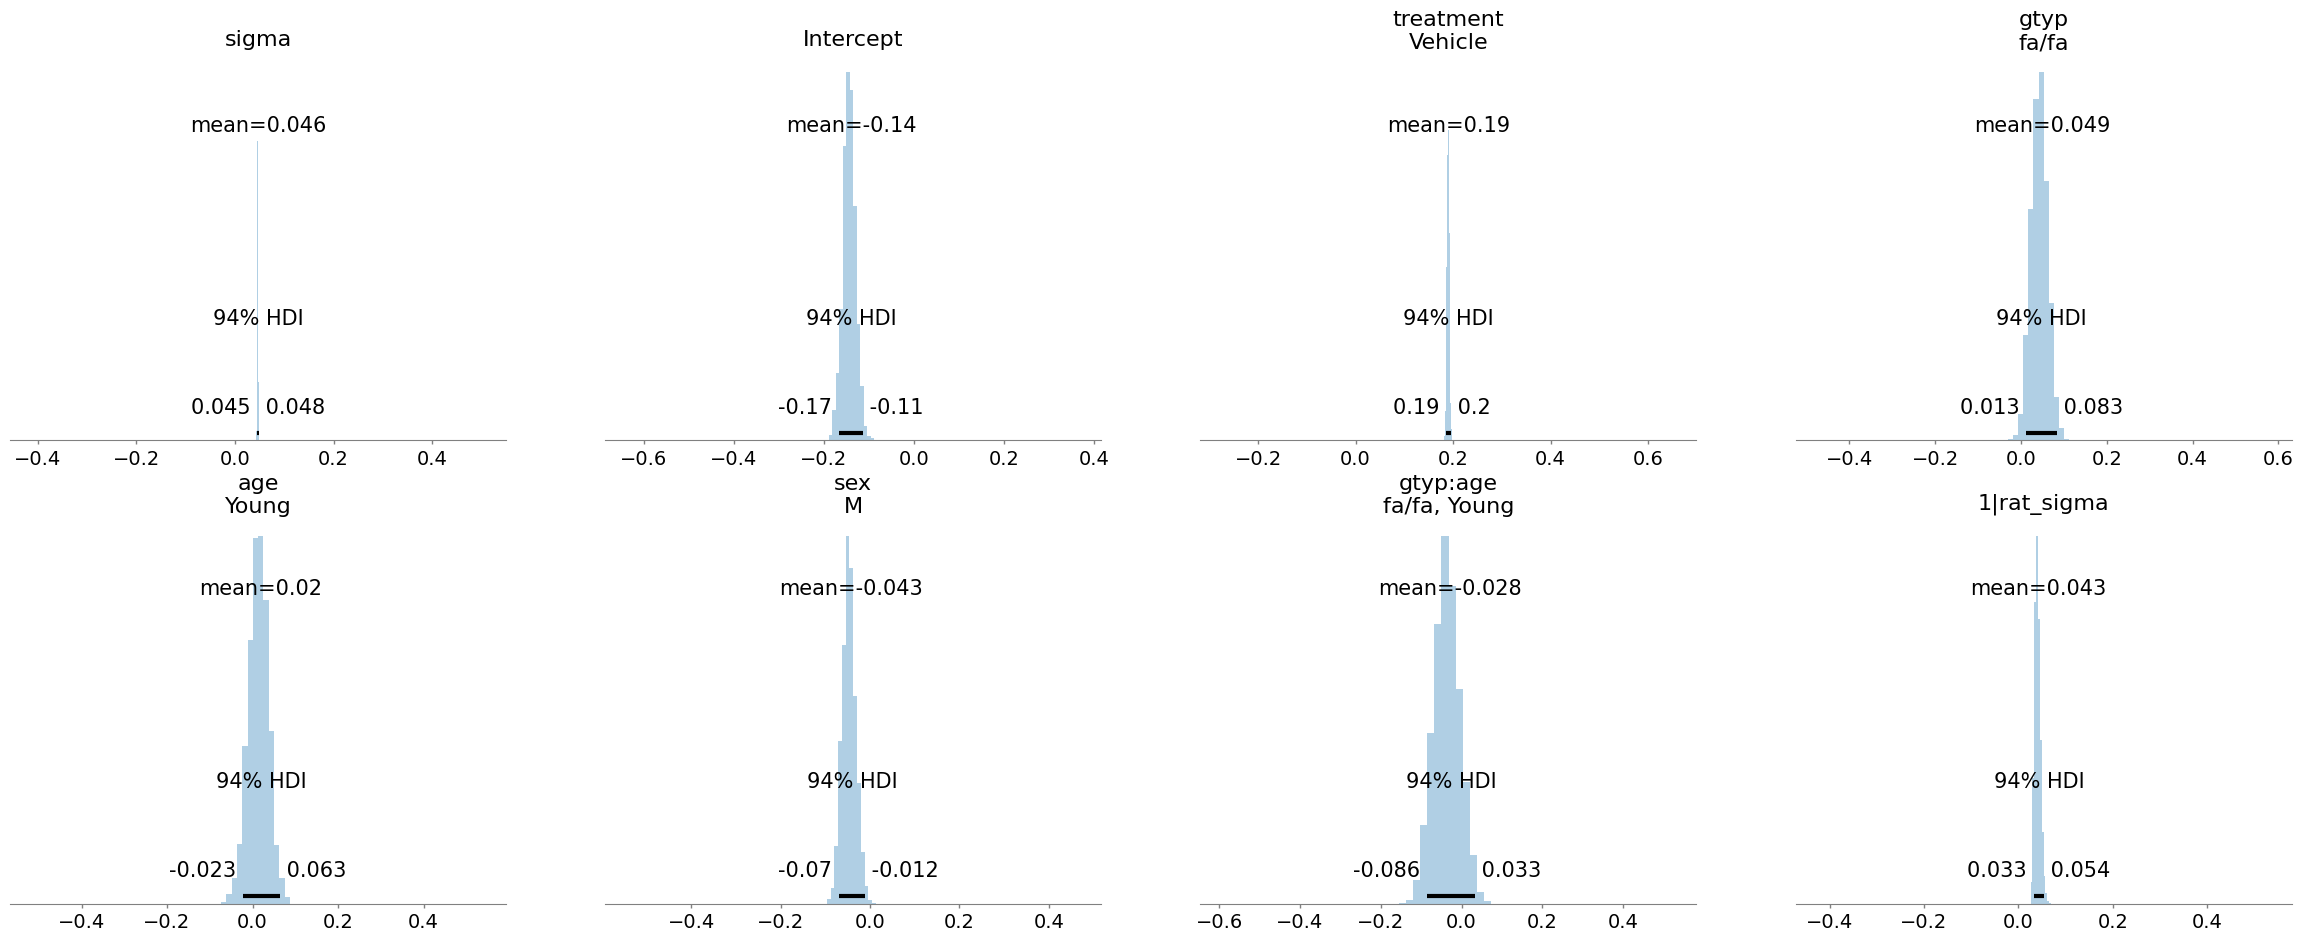

In [10]:
az.plot_posterior(idata_log, var_names=["~1|rat", "~mu"], kind="hist")